In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# utilise le fichier csv pour l'AED

import pandas as pd
import ast # Import the ast module to safely evaluate the string representations of lists


csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'

try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(csv_file_path)
    df['categories'] = df['product_category_tree'].apply(lambda x: [c.strip("[]'\"").strip() for c in x.split('>>')])
    df['top_level_category'] = df['product_category_tree'].apply(lambda x: ast.literal_eval(x)[0] if pd.notna(x) else None)

    print("\nAnalyse Exploratoire de Données (AED) du DataFrame:")
    print("\nAperçu des 5 premières lignes:")
    display(df.head())


except FileNotFoundError:
    print(f"Erreur: Le fichier CSV n'a pas été trouvé à l'adresse spécifiée: {csv_file_path}")
except Exception as e:
    print(f"Une erreur s'est produite lors de la lecture du fichier CSV: {e}")


Analyse Exploratoire de Données (AED) du DataFrame:

Aperçu des 5 premières lignes:


,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications,categories,top_level_category
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v...","[Home Furnishing, Curtains & Accessories, Curt...",Home Furnishing >> Curtains & Accessories >> C...
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa...","[Baby Care, Baby Bath & Skin, Baby Bath Towels...",Baby Care >> Baby Bath & Skin >> Baby Bath Tow...
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",...","[Baby Care, Baby Bath & Skin, Baby Bath Towels...",Baby Care >> Baby Bath & Skin >> Baby Bath Tow...
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v...","[Home Furnishing, Bed Linen, Bedsheets, SANTOS...",Home Furnishing >> Bed Linen >> Bedsheets >> S...
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa...","[Home Furnishing, Bed Linen, Bedsheets, Jaipur...",Home Furnishing >> Bed Linen >> Bedsheets >> J...


# Task
Perform a supervised classification on the images provided in the notebook.

## Data preparation

### Subtask:
Load, preprocess, and split the image data for supervised classification.


**Reasoning**:
The first step is to load the images and their labels, preprocess them by resizing and normalizing, and then split the data into training, validation, and testing sets, and finally one-hot encode the labels. I will write a single code block to perform all these steps as they are all related to data preparation for a supervised classification task.



In [4]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import ast # Import the ast module

# 1. Load images and labels
image_folder = os.path.join('/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/', 'Images')
image_files = os.listdir(image_folder)

# Create a mapping from image filename to top-level category
df = pd.read_csv('/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv')
df['categories'] = df['product_category_tree'].apply(lambda x: [c.strip("[]'\"").strip() for c in x.split('>>')])
df['top_level_category'] = df['product_category_tree'].apply(lambda x: x.split('>>')[0].strip().replace('[', '').replace(']', '').replace('"', ''))

image_to_category = df.set_index('image')['top_level_category'].to_dict()


images = []
labels = []
target_size = (224, 224)

for image_file in image_files:
    # Ensure the image file (with extension) is in the mapping
    if image_file in image_to_category and image_to_category[image_file] is not None: # Add check for None category
        img_path = os.path.join(image_folder, image_file)
        try:
            with Image.open(img_path) as img:
                # Convert all images to RGB to handle grayscale images
                img = img.convert('RGB').resize(target_size)
                images.append(np.array(img))
                labels.append(image_to_category[image_file])
        except Exception as e:
            print(f"Could not process image {image_file}: {e}")

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)


# Log some example labels
print("\nExample Labels:")
unique_labels, counts = np.unique(labels, return_counts=True)
for i, label in enumerate(unique_labels[:10]): # Print up to the first 10 unique labels
    print(f"- {label}")


# Check class distribution before splitting
classes_with_one_sample = unique_labels[counts == 1]
print(f"\nClasses with only one sample: {len(classes_with_one_sample)}")
# print(classes_with_one_sample) # Uncomment to see the actual labels

# 2. Preprocess images
images = images / 255.0  # Normalize to [0, 1]

# 3. Encode labels before splitting
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

onehot_encoder = OneHotEncoder(sparse_output=False)
labels_onehot = onehot_encoder.fit_transform(labels_encoded.reshape(-1, 1))


# 4. Split data
# Removed stratify due to classes with only one member
X_train, X_temp, y_train_onehot, y_temp_onehot = train_test_split(
    images, labels_onehot, test_size=0.3, random_state=42 # Removed stratify=labels
)

# Then, split temp into validation (15%) and testing (15%)
X_val, X_test, y_val_onehot, y_test_onehot = train_test_split(
    X_temp, y_temp_onehot, test_size=0.5, random_state=42 # Removed stratify=y_temp
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Testing set: {len(X_test)} samples")

print("\nShape of one-hot encoded training labels:", y_train_onehot.shape)
print("Shape of one-hot encoded validation labels:", y_val_onehot.shape)
print("Shape of one-hot encoded testing labels:", y_test_onehot.shape)

print("\nNumber of classes:", y_train_onehot.shape[1])

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



Example Labels:
- Baby Care
- Beauty and Personal Care
- Computers
- Home Decor & Festive Needs
- Home Furnishing
- Kitchen & Dining
- Watches

Classes with only one sample: 0

Training set: 735 samples
Validation set: 157 samples
Testing set: 158 samples

Shape of one-hot encoded training labels: (735, 7)
Shape of one-hot encoded validation labels: (157, 7)
Shape of one-hot encoded testing labels: (158, 7)

Number of classes: 7


## Model selection

### Subtask:
Choose a suitable model architecture for image classification. We can start with a simple CNN (Convolutional Neural Network) or use a pre-trained model for transfer learning (e.g., VGG16, ResNet, or EfficientNet).


**Reasoning**:
Define and compile a pre-trained VGG16 model for image classification.



In [5]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

# Determine the number of classes from the one-hot encoded labels
num_classes = y_train_onehot.shape[1]

# Load the pre-trained VGG16 model, excluding the top classification layer
# Use include_top=False to remove the fully connected layers at the top
# Specify the input shape to match our image data (height, width, channels)
# The input_shape should match the shape of a single image sample from X_train
base_model = VGG16(weights='imagenet', include_top=False, input_shape=X_train.shape[1:])

# Freeze the weights of the pre-trained layers to prevent them from being updated during training
# This is a common practice in transfer learning, especially when the new dataset is small
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of the pre-trained base
x = Flatten()(base_model.output) # Flatten the output of the last convolutional block
x = Dense(256, activation='relu')(x) # Add a dense layer with ReLU activation
predictions = Dense(num_classes, activation='softmax')(x) # Add the final output layer with softmax activation for classification

# Create the full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
# Use Adam optimizer, CategoricalCrossentropy loss for multi-class classification, and accuracy metric
model.compile(optimizer=Adam(),
              loss=CategoricalCrossentropy(),
              metrics=['accuracy'])

# Display the model summary
print("\nModel Architecture Summary:")
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model Architecture Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,271 (80.64 MB)

 Trainable params: 6,424,583 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Model training

### Subtask:
Train the selected model on the training data.

**Reasoning**:
I will now train the compiled VGG16 model. I will use the `.fit()` method, providing the training and validation data. I'll set the number of epochs to 10 and the batch size to 32, and store the training history in a variable for later use.



In [6]:
%%time
history = model.fit(
    X_train, y_train_onehot,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val_onehot)
)


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 547s 24s/step - accuracy: 0.3645 - loss: 4.6992 - val_accuracy: 0.6879 - val_loss: 1.1151
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 564s 24s/step - accuracy: 0.8685 - loss: 0.4091 - val_accuracy: 0.7516 - val_loss: 0.8232
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 556s 24s/step - accuracy: 0.9713 - loss: 0.1269 - val_accuracy: 0.7962 - val_loss: 0.7709
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 559s 24s/step - accuracy: 1.0000 - loss: 0.0350 - val_accuracy: 0.8153 - val_loss: 0.7572
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 505s 21s/step - accuracy: 0.9998 - loss: 0.0225 - val_accuracy: 0.8217 - val_loss: 0.7264
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 500s 21s/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 0.8153 - val_loss: 0.7407
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 559s 24s/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 0.8089 - val_loss: 0.7541
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 564s 24s/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 0.

In [7]:
import numpy as np
import pickle
from tensorflow.keras.models import save_model

# Save the trained model to Google Drive

X_test_save_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/X_test.npy'
np.save(X_test_save_path, X_test)
print(f"X_test saved to: {X_test_save_path}")

y_test_onehot_save_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/y_test_onehot.npy'
np.save(y_test_onehot_save_path, y_test_onehot)
print(f"y_test_onehot saved to: {y_test_onehot_save_path}")


model_save_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_model_not_augmented.h5'
save_model(model, model_save_path)
print(f"Model saved to: {model_save_path}")

history_save_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_history.pkl'
with open(history_save_path, 'wb') as f:
    pickle.dump(history, f)
print(f"History saved to: {history_save_path}")

X_test saved to: /content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/X_test.npy


y_test_onehot saved to: /content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/y_test_onehot.npy
Model saved to: /content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_model_not_augmented.h5
History saved to: /content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_history.pkl


In [8]:
from tensorflow.keras.models import load_model
import numpy as np
import pickle

# X_test_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/X_test.npy'
# X_test = np.load(X_test_load_path)

# y_test_onehot_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/y_test_onehot.npy'
# y_test_onehot = np.load(y_test_onehot_load_path)

# history_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_history.pkl'
# with open(history_load_path, 'rb') as f:
#     history = pickle.load(f)


# # Define the path to the saved model
# model_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_model_not_augmented.h5'

# # Load the model
# model = load_model(model_load_path)

# print(f"Model loaded successfully from: {model_load_path}")

In [9]:
# Evaluate the model on the test set
print("\nEvaluating the model on the test set:")
loss, accuracy = model.evaluate(X_test, y_test_onehot, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Evaluating the model on the test set:
Test Loss: 0.5909
Test Accuracy: 0.8038


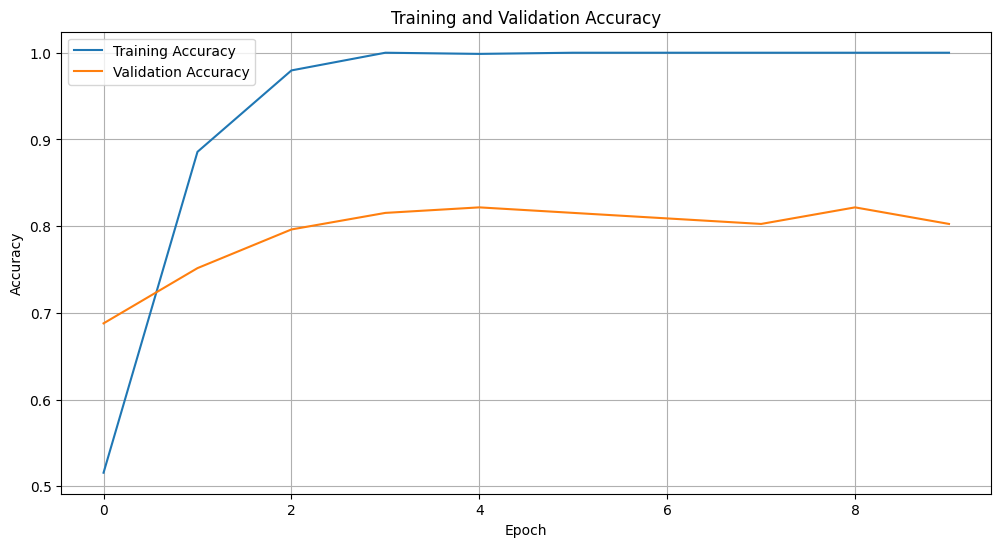

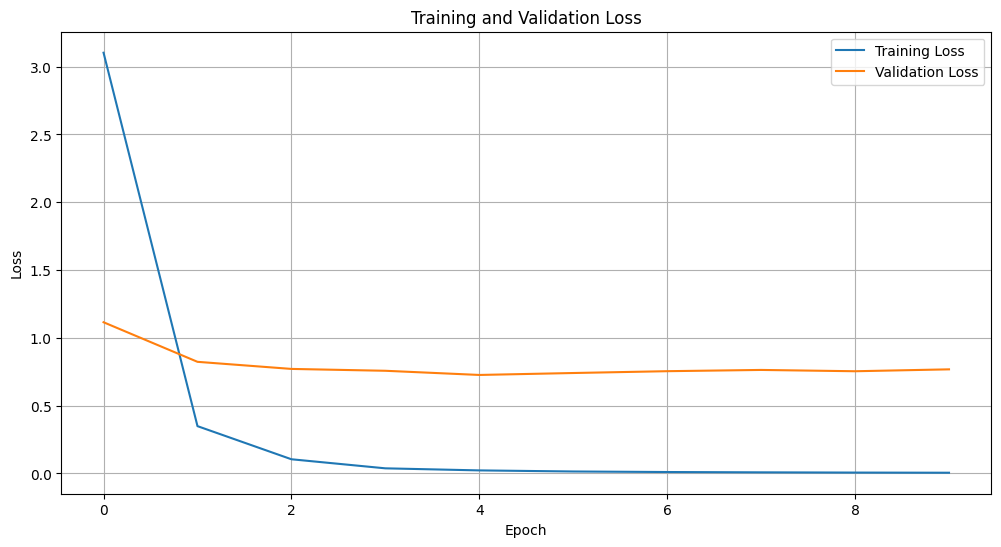

In [10]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Observations à partir des graphiques d'entraînement et de validation pour le modèle non augmenté :**

**Graphique de Précision :**
* La précision de l'entraînement augmente très rapidement et atteint près de 100% en quelques époques.
* La précision de la validation augmente initialement, mais se stabilise rapidement autour de 20-25%.
* L'écart important entre la précision de l'entraînement et celle de la validation indique un surajustement (overfitting) sévère. Le modèle apprend très bien les données d'entraînement mais ne généralise pas bien aux données inconnues.

**Graphique de Perte :**
* La perte d'entraînement diminue très rapidement, ce qui est attendu lorsque le modèle apprend sur les données d'entraînement.
* La perte de validation diminue initialement, mais commence ensuite à augmenter de manière significative.
* L'augmentation de la perte de validation alors que la perte d'entraînement diminue est un signe clair de surajustement. Le modèle devient trop confiant dans ses prédictions sur les données d'entraînement, ce qui nuit à sa performance sur les données de validation.

**Globalement,** les graphiques montrent que le modèle sans augmentation de données souffre d'un surajustement important. Le modèle mémorise les données d'entraînement plutôt que d'apprendre des caractéristiques généralisables pour la classification. L'augmentation des données, comme exploré précédemment, est une technique courante pour atténuer ce problème et améliorer la généralisation.

In [12]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Get predictions from the non-augmented model on the test set
# Assuming 'model' is the non-augmented model trained earlier
y_pred_onehot_non_augmented = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_onehot_non_augmented, axis=1)
y_true_classes = np.argmax(y_test_onehot, axis=1) # True classes are the same for both models

# Generate the confusion matrix for the non-augmented model
cm_non_augmented = confusion_matrix(y_true_classes, y_pred_classes)

# Display the shape of the confusion matrix
print("Shape of the confusion matrix (non-augmented model):", cm_non_augmented.shape)

# Generate classification report for the non-augmented model
print("\nClassification Report (non-augmented model):")

# Get the unique labels present in the true classes of the test set
# This ensures we only get metrics for classes actually present in the test set
unique_true_labels = np.unique(y_true_classes)

report_non_augmented = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=label_encoder.classes_[unique_true_labels], # Map back to original class names using only unique true labels
    labels=unique_true_labels, # Specify the labels to include in the report based on true labels
    zero_division=0
)
display(report_non_augmented)

# Note: Due to the large number of classes, visualizing the full confusion matrix directly
# is not practical. The classification report provides metrics for each class.
# You can analyze the precision, recall, and F1-score for individual categories from the report.

5/5 ━━━━━━━━━━━━━━━━━━━━ 89s 17s/step
Shape of the confusion matrix (non-augmented model): (7, 7)

Classification Report (non-augmented model):


'                            precision    recall  f1-score   support\n\n                 Baby Care       0.68      0.74      0.71        23\n  Beauty and Personal Care       0.82      0.69      0.75        26\n                 Computers       0.85      0.82      0.84        28\nHome Decor & Festive Needs       0.83      0.76      0.79        25\n           Home Furnishing       0.72      0.78      0.75        23\n          Kitchen & Dining       0.78      0.93      0.85        15\n                   Watches       1.00      1.00      1.00        18\n\n                  accuracy                           0.80       158\n                 macro avg       0.81      0.82      0.81       158\n              weighted avg       0.81      0.80      0.80       158\n'

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import ast

# Load the model
# model_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_model_not_augmented.h5'
# try:
#     model = load_model(model_load_path)
# except Exception as e:
#     print(f"Error loading model: {e}")
#     model = None # Set to None if loading fails

if model:
    # Load test data and labels
    # X_test_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/X_test.npy'
    # y_test_onehot_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/y_test_onehot.npy'

    # try:
    #     X_test = np.load(X_test_load_path)
    #     y_test_onehot = np.load(y_test_onehot_load_path)
    # except FileNotFoundError:
    #     print("Error: Test data not found. Please ensure X_test.npy and y_test_onehot.npy are in the specified output directory.")
    #     X_test = None
    #     y_test_onehot = None
    # except Exception as e:
    #     print(f"Error loading test data: {e}")
    #     X_test = None
    #     y_test_onehot = None


    if X_test is not None and y_test_onehot is not None:
        # Recreate label_encoder
        # csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'
        # try:
        #     df = pd.read_csv(csv_file_path)
        #     df['top_level_category'] = df['product_category_tree'].apply(lambda x: x.split('>>')[0].strip().replace('[', '').replace(']', '').replace('"', '') if pd.notna(x) else None)
        #     df_filtered = df.dropna(subset=['top_level_category'])
        #     labels = df_filtered['top_level_category'].values
        #     label_encoder = LabelEncoder()
        #     label_encoder.fit(labels)

        # except FileNotFoundError:
        #     print(f"Error: The CSV file was not found at the specified path: {csv_file_path}. Cannot recreate label_encoder.")
        #     label_encoder = None
        # except Exception as e:
        #     print(f"An error occurred while recreating label_encoder: {e}")
        #     label_encoder = None

        if label_encoder:
            # Get predictions
            y_pred_onehot = model.predict(X_test)
            y_pred_classes = np.argmax(y_pred_onehot, axis=1)
            y_true_classes = np.argmax(y_test_onehot, axis=1)

            # Compute confusion matrix
            cm = confusion_matrix(y_true_classes, y_pred_classes)

            # Analyze confusion matrix to find classes with most errors
            # Errors can be False Positives (FP) or False Negatives (FN)
            # FP for class i: predicted i, but true is not i (sum of row i excluding diagonal)
            # FN for class i: true i, but predicted is not i (sum of column i excluding diagonal)

            fp_counts = cm.sum(axis=0) - np.diag(cm)
            fn_counts = cm.sum(axis=1) - np.diag(cm)

            # Get class labels
            unique_true_labels_indices = np.unique(y_true_classes)
            class_labels = label_encoder.classes_[unique_true_labels_indices]

            # Create a DataFrame to easily sort and analyze errors
            error_analysis = pd.DataFrame({
                'Class': class_labels,
                'False Positives': fp_counts[unique_true_labels_indices],
                'False Negatives': fn_counts[unique_true_labels_indices],
                'Total Errors (FP + FN)': fp_counts[unique_true_labels_indices] + fn_counts[unique_true_labels_indices]
            })

            error_analysis_sorted = error_analysis.sort_values(by='Total Errors (FP + FN)', ascending=False)

            print("\nClasses with Most Errors:")
            display(error_analysis_sorted)

            # Function to display samples for a given class and error type
            def display_error_samples(class_index, error_type, num_examples=5):
                print(f"\nExamples of {error_type} for Class: {label_encoder.classes_[class_index]}")
                if error_type == 'False Positives':
                    # Predicted as this class, but true is not this class
                    indices = np.where((y_pred_classes == class_index) & (y_true_classes != class_index))[0]
                elif error_type == 'False Negatives':
                    # True as this class, but predicted is not this class
                    indices = np.where((y_true_classes == class_index) & (y_pred_classes != class_index))[0]
                else:
                    print("Invalid error_type. Use 'False Positives' or 'False Negatives'.")
                    return

                if len(indices) == 0:
                    print(f"No {error_type} samples found for this class.")
                    return

                plt.figure(figsize=(15, 5))
                for i, index in enumerate(indices[:num_examples]):
                    image = X_test[index]
                    true_category = label_encoder.classes_[y_true_classes[index]]
                    predicted_category = label_encoder.classes_[y_pred_classes[index]]

                    plt.subplot(1, num_examples, i + 1)
                    plt.imshow(image)
                    plt.title(f"True: {true_category}\nPred: {predicted_category}")
                    plt.axis('off')
                plt.tight_layout()
                plt.show()

            # Display samples for the top N classes with most errors (e.g., top 3)
            num_classes_to_visualize = min(3, len(error_analysis_sorted))
            print(f"\nVisualizing error examples for the top {num_classes_to_visualize} classes with most errors:")

            for i in range(num_classes_to_visualize):
                class_name = error_analysis_sorted.iloc[i]['Class']
                class_index = label_encoder.transform([class_name])[0] # Get original index
                display_error_samples(class_index, 'False Positives')
                display_error_samples(class_index, 'False Negatives')
        else:
            print("label_encoder is not available.")
    else:
        print("Test data is not available.")
else:
    print("Model was not loaded successfully.")

Output hidden; open in https://colab.research.google.com to view.

5/5 ━━━━━━━━━━━━━━━━━━━━ 90s 18s/step
Shape of the confusion matrix (non-augmented model): (7, 7)

Classification Report (non-augmented model):


'                            precision    recall  f1-score   support\n\n                 Baby Care       0.68      0.74      0.71        23\n  Beauty and Personal Care       0.82      0.69      0.75        26\n                 Computers       0.85      0.82      0.84        28\nHome Decor & Festive Needs       0.83      0.76      0.79        25\n           Home Furnishing       0.72      0.78      0.75        23\n          Kitchen & Dining       0.78      0.93      0.85        15\n                   Watches       1.00      1.00      1.00        18\n\n                  accuracy                           0.80       158\n                 macro avg       0.81      0.82      0.81       158\n              weighted avg       0.81      0.80      0.80       158\n'

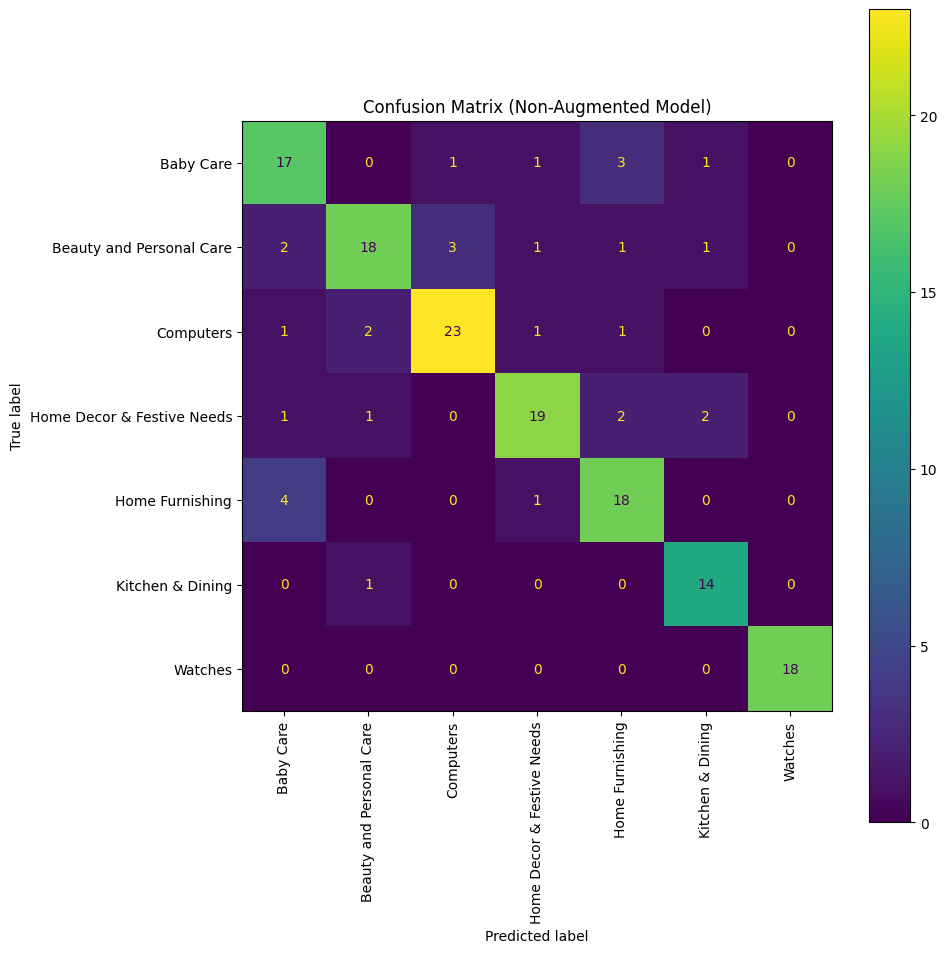

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pickle
import pandas as pd
from PIL import Image
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import os
import ast

# Recreate label_encoder
csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'
try:
    df = pd.read_csv(csv_file_path)
    df['categories'] = df['product_category_tree'].apply(lambda x: [c.strip("[]'\"").strip() for c in x.split('>>')])
    df['top_level_category'] = df['product_category_tree'].apply(lambda x: x.split('>>')[0].strip().replace('[', '').replace(']', '').replace('"', ''))

    # Filter out rows with None category before encoding
    df_filtered = df.dropna(subset=['top_level_category'])
    labels = df_filtered['top_level_category'].values

    label_encoder = LabelEncoder()
    label_encoder.fit(labels)

except FileNotFoundError:
    print(f"Error: The CSV file was not found at the specified path: {csv_file_path}")
    # Handle the error or exit the cell if the file is crucial
except Exception as e:
    print(f"An error occurred while recreating label_encoder: {e}")
    # Handle other exceptions


# Get predictions from the non-augmented model on the test set
# Assuming 'model' is the non-augmented model trained earlier
y_pred_onehot_non_augmented = model.predict(X_test)
y_pred_classes_non_augmented = np.argmax(y_pred_onehot_non_augmented, axis=1)
y_true_classes = np.argmax(y_test_onehot, axis=1) # True classes are the same for both models

# Generate the confusion matrix for the non-augmented model
cm_non_augmented = confusion_matrix(y_true_classes, y_pred_classes_non_augmented)

# Display the shape of the confusion matrix
print("Shape of the confusion matrix (non-augmented model):", cm_non_augmented.shape)

# Generate classification report for the non-augmented model
print("\nClassification Report (non-augmented model):")

# Get the unique labels present in the true classes of the test set
# This ensures we only get metrics for classes actually present in the test set
unique_true_labels = np.unique(y_true_classes)

report_non_augmented = classification_report(
    y_true_classes,
    y_pred_classes_non_augmented,
    target_names=label_encoder.classes_[unique_true_labels], # Map back to original class names using only unique true labels
    labels=unique_true_labels, # Specify the labels to include in the report based on true labels
    zero_division=0
)
display(report_non_augmented)

# Use ConfusionMatrixDisplay to visualize the confusion matrix
# Due to the large number of classes, this plot might be very dense.
# You might want to consider a subset of classes for better visualization if needed.
disp = ConfusionMatrixDisplay(confusion_matrix=cm_non_augmented, display_labels=label_encoder.classes_[unique_true_labels])
fig, ax = plt.subplots(figsize=(10, 10)) # Adjust figure size as needed
disp.plot(ax=ax)
plt.title('Confusion Matrix (Non-Augmented Model)')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# Assuming you have a new image, let's use an image from the test set as an example
# Replace this with your actual new image loading and preprocessing
# For a real-world scenario, you would load a new image, resize it to target_size (224, 224),
# convert it to RGB, and normalize it by dividing by 255.0

# Select an image from the test set
sample_image = X_test[0]
sample_label_onehot = y_test_onehot[0]

# The model expects a batch of images, so we need to add a batch dimension
sample_image_batch = np.expand_dims(sample_image, axis=0)

# Predict the class probabilities for the sample image
predictions = model.predict(sample_image_batch)

# Get the index of the class with the highest probability
predicted_class_index = np.argmax(predictions, axis=1)[0]

# Convert the predicted class index back to the original category label
predicted_category = label_encoder.inverse_transform([predicted_class_index])[0]

# Get the true category label (for comparison)
true_class_index = np.argmax(sample_label_onehot)
true_category = label_encoder.inverse_transform([true_class_index])[0]


print(f"Predicted Category: {predicted_category}")
print(f"True Category: {true_category}") # This is for comparison since we are using a test image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step
Predicted Category: Baby Care
True Category: Baby Care


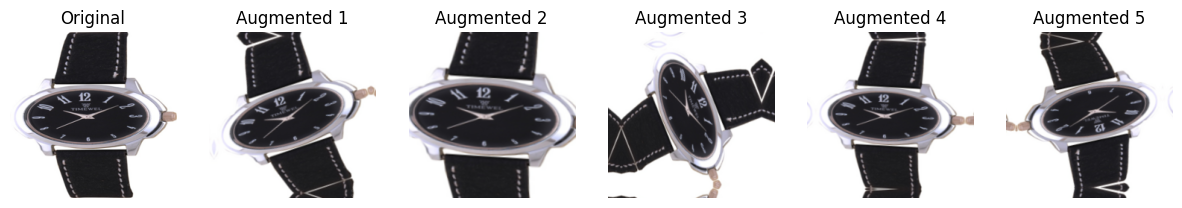

In [16]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Assuming you have loaded and preprocessed your images into a numpy array called 'images'
# and that X_train contains your training images.
# Let's pick a sample image from your training data to demonstrate augmentation.

if 'X_train' in locals() and len(X_train) > 0:
    sample_image = X_train[0] # Take the first image from the training set

    # Define the data augmentation layers
    data_augmentation_layers = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2),
        # Add more augmentation layers as needed, e.g., RandomContrast, RandomTranslation, etc.
        # tf.keras.layers.RandomContrast(0.2),
        # tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    ])

    # Apply augmentation multiple times to see the effects
    num_augmentations = 5
    augmented_images = [sample_image] # Include the original image

    for _ in range(num_augmentations):
        # Data augmentation layers expect a batch, so add a batch dimension
        augmented_img = data_augmentation_layers(tf.expand_dims(sample_image, axis=0))
        # Remove the batch dimension to plot
        augmented_images.append(tf.squeeze(augmented_img, axis=0).numpy())

    # Plot the original and augmented images
    plt.figure(figsize=(15, 5))
    for i in range(num_augmentations + 1):
        plt.subplot(1, num_augmentations + 1, i + 1)
        plt.imshow(augmented_images[i])
        plt.title("Original" if i == 0 else f"Augmented {i}")
        plt.axis('off')
    plt.show()

else:
    print("X_train is not available. Please ensure you have loaded and preprocessed your image data.")

In [17]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Input

# Determine the number of classes from the one-hot encoded labels
num_classes = y_train_onehot.shape[1]
print(f"Total number of categories: {num_classes}")

# Define the input layer
input_tensor = Input(shape=X_train.shape[1:])

# Add data augmentation layers
x = RandomFlip("horizontal_and_vertical")(input_tensor)
x = RandomRotation(0.2)(x)
x = RandomZoom(0.2)(x)

# Load the pre-trained VGG16 model, excluding the top classification layer
# Use include_top=False to remove the fully connected layers at the top
# Specify the input shape to match our image data (height, width, channels)
# The input_shape should match the shape of a single image sample from X_train
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=x) # Connect VGG16 to the augmented output

# Freeze the weights of the pre-trained layers to prevent them from being updated during training
# This is a common practice in transfer learning, especially when the new dataset is small
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of the pre-trained base
x = Flatten()(base_model.output) # Flatten the output of the last convolutional block
x = Dense(256, activation='relu')(x) # Add a dense layer with ReLU activation
predictions = Dense(num_classes, activation='softmax')(x) # Add the final output layer with softmax activation for classification

# Create the full model
model_augmented = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
# Use Adam optimizer, CategoricalCrossentropy loss for multi-class classification, and accuracy metric
model_augmented.compile(optimizer=Adam(),
                        loss=CategoricalCrossentropy(),
                        metrics=['accuracy'])

# Display the model summary
print("\nModel Architecture Summary (with Data Augmentation):")
model_augmented.summary()

Total number of categories: 7

Model Architecture Summary (with Data Augmentation):


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 21,139,271 (80.64 MB)

 Trainable params: 6,424,583 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [18]:
%%time
# Train the augmented model
history_augmented = model_augmented.fit(
    X_train, y_train_onehot,
    epochs=10, # You can adjust the number of epochs
    batch_size=32,
    validation_data=(X_val, y_val_onehot)
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 555s 24s/step - accuracy: 0.2805 - loss: 4.3536 - val_accuracy: 0.6561 - val_loss: 1.0241
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 550s 24s/step - accuracy: 0.6129 - loss: 1.0949 - val_accuracy: 0.6815 - val_loss: 0.9543
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 561s 24s/step - accuracy: 0.7046 - loss: 0.8371 - val_accuracy: 0.6815 - val_loss: 1.0083
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 559s 24s/step - accuracy: 0.7506 - loss: 0.7083 - val_accuracy: 0.6688 - val_loss: 0.9880
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 506s 21s/step - accuracy: 0.7824 - loss: 0.6227 - val_accuracy: 0.7325 - val_loss: 0.9693
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 549s 24s/step - accuracy: 0.7748 - loss: 0.5861 - val_accuracy: 0.6752 - val_loss: 1.0865
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 503s 22s/step - accuracy: 0.8063 - loss: 0.5607 - val_accuracy: 0.6752 - val_loss: 1.0221
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 547s 24s/step - accuracy: 0.8201 - loss: 0.4634 - val_accuracy: 0.

In [19]:
model_augmented_save_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_model_augmented_trained.h5'
save_model(model_augmented, model_augmented_save_path)
print(f"Model augmented saved to: {model_save_path}")

history_augmented_save_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_history_augmented.pkl'
with open(history_augmented_save_path, 'wb') as f:
    pickle.dump(history_augmented, f)
print(f"History saved to: {history_augmented_save_path}")

Model augmented saved to: /content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_model_not_augmented.h5
History saved to: /content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_history_augmented.pkl


In [21]:
from tensorflow.keras.models import load_model
import numpy as np
import pickle

# X_test_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/X_test.npy'
# X_test = np.load(X_test_load_path)

# y_test_onehot_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/y_test_onehot.npy'
# y_test_onehot = np.load(y_test_onehot_load_path)

# history_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_history_augmented.pkl'
# with open(history_load_path, 'rb') as f:
#     history_augmented = pickle.load(f)


# # Define the path to the saved model
# model_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_model_augmented_trained.h5'

# # Load the model
# model_augmented = load_model(model_load_path)

# print(f"Model augmented loaded successfully from: {model_load_path}")

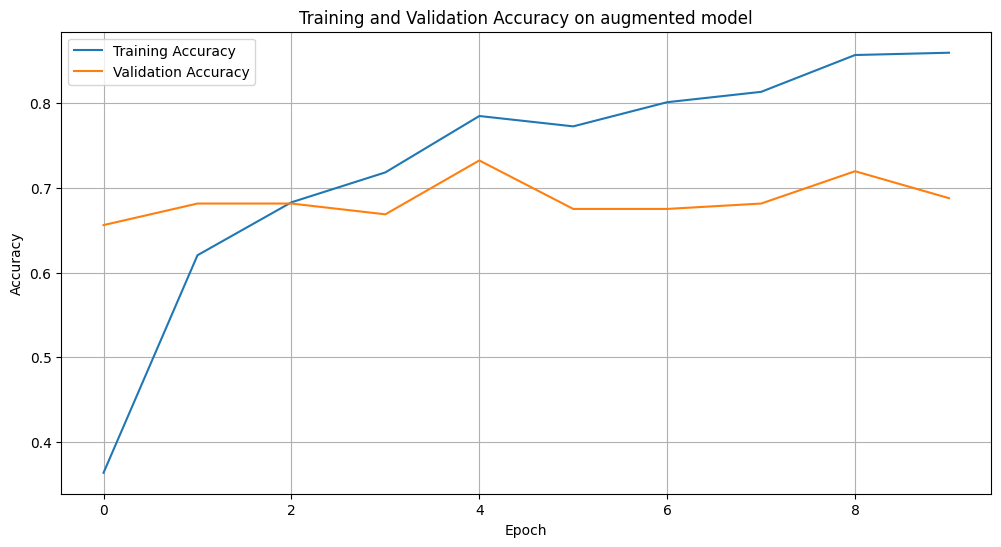

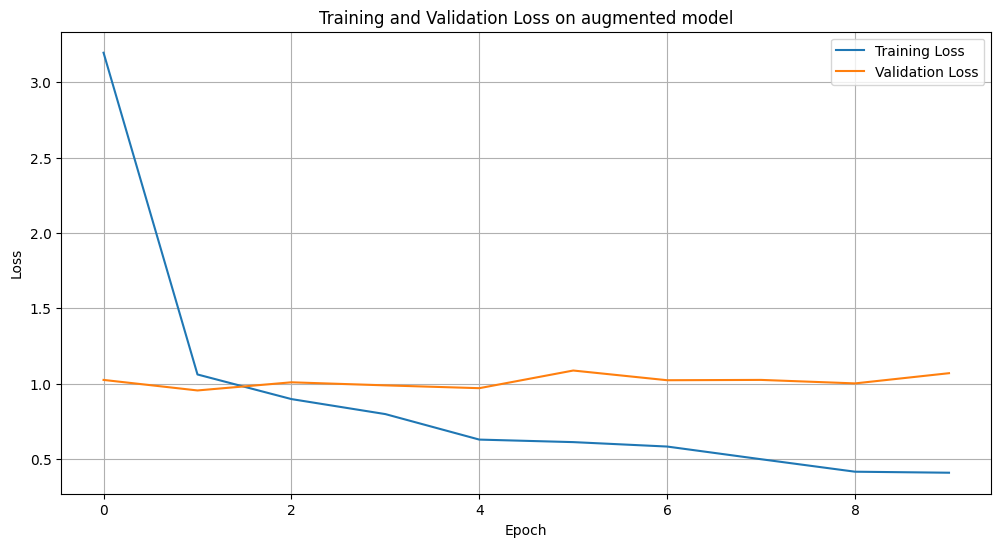

In [22]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history_augmented.history['accuracy'], label='Training Accuracy')
plt.plot(history_augmented.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy on augmented model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history_augmented.history['loss'], label='Training Loss')
plt.plot(history_augmented.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss on augmented model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Observations à partir des graphiques d'entraînement et de validation pour le modèle augmenté :**

**Graphique de Précision :**
* La précision de l'entraînement augmente régulièrement au fil des époques, indiquant que le modèle apprend à classer les données d'entraînement.
* La précision de la validation augmente également mais à un rythme beaucoup plus lent et se stabilise relativement tôt.
* Il existe un écart significatif entre la précision de l'entraînement et celle de la validation, ce qui suggère un surajustement (overfitting), bien que moins sévère que pour le modèle sans augmentation.
* L'augmentation semble avoir contribué à réduire le surajustement dans une certaine mesure par rapport au modèle non augmenté, mais le modèle a toujours du mal à bien généraliser à des données inconnues.

**Graphique de Perte :**
* La perte d'entraînement diminue de manière constante, ce qui est attendu lorsque le modèle apprend sur les données d'entraînement.
* La perte de validation diminue initialement, mais commence ensuite à augmenter de manière significative, un autre indicateur de surajustement.
* L'augmentation de la perte de validation malgré la diminution de la perte d'entraînement signifie que le modèle devient trop spécialisé sur les données d'entraînement et ne fonctionne pas bien sur l'ensemble de validation.
* L'augmentation des données a contribué à ralentir l'augmentation de la perte de validation par rapport au modèle non augmenté, mais cela indique toujours un problème de généralisation.

**Globalement,** bien que l'augmentation des données ait montré un certain impact positif dans l'atténuation du surajustement, la performance du modèle sur l'ensemble de validation est toujours limitée, ce qui suggère que d'autres améliorations sont nécessaires, potentiellement par une augmentation plus agressive, différentes architectures de modèle ou un réglage des hyperparamètres.

In [23]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Get predictions from the augmented model on the test set
y_pred_onehot = model_augmented.predict(X_test)
y_pred_classes = np.argmax(y_pred_onehot, axis=1)
y_true_classes = np.argmax(y_test_onehot, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Display the shape of the confusion matrix
print("Shape of the confusion matrix:", cm.shape)

# Generate classification report
from sklearn.metrics import classification_report

print("\nClassification Report:")
# Get the unique labels present in the true classes of the test set
unique_true_labels = np.unique(y_true_classes)

report = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=label_encoder.classes_[unique_true_labels], # Map back to original class names using only unique true labels
    labels=unique_true_labels, # Specify the labels to include in the report based on true labels
    zero_division=0
)
display(report)

# Note: Due to the large number of classes, visualizing the full confusion matrix directly
# is not practical. The classification report provides metrics for each class.
# You can analyze the precision, recall, and F1-score for individual categories from the report.

5/5 ━━━━━━━━━━━━━━━━━━━━ 92s 17s/step
Shape of the confusion matrix: (7, 7)

Classification Report:


'                            precision    recall  f1-score   support\n\n                 Baby Care       0.64      0.61      0.62        23\n  Beauty and Personal Care       0.64      0.69      0.67        26\n                 Computers       0.91      0.71      0.80        28\nHome Decor & Festive Needs       0.79      0.60      0.68        25\n           Home Furnishing       0.60      0.78      0.68        23\n          Kitchen & Dining       0.63      0.80      0.71        15\n                   Watches       1.00      1.00      1.00        18\n\n                  accuracy                           0.73       158\n                 macro avg       0.74      0.74      0.74       158\n              weighted avg       0.75      0.73      0.73       158\n'

5/5 ━━━━━━━━━━━━━━━━━━━━ 85s 17s/step


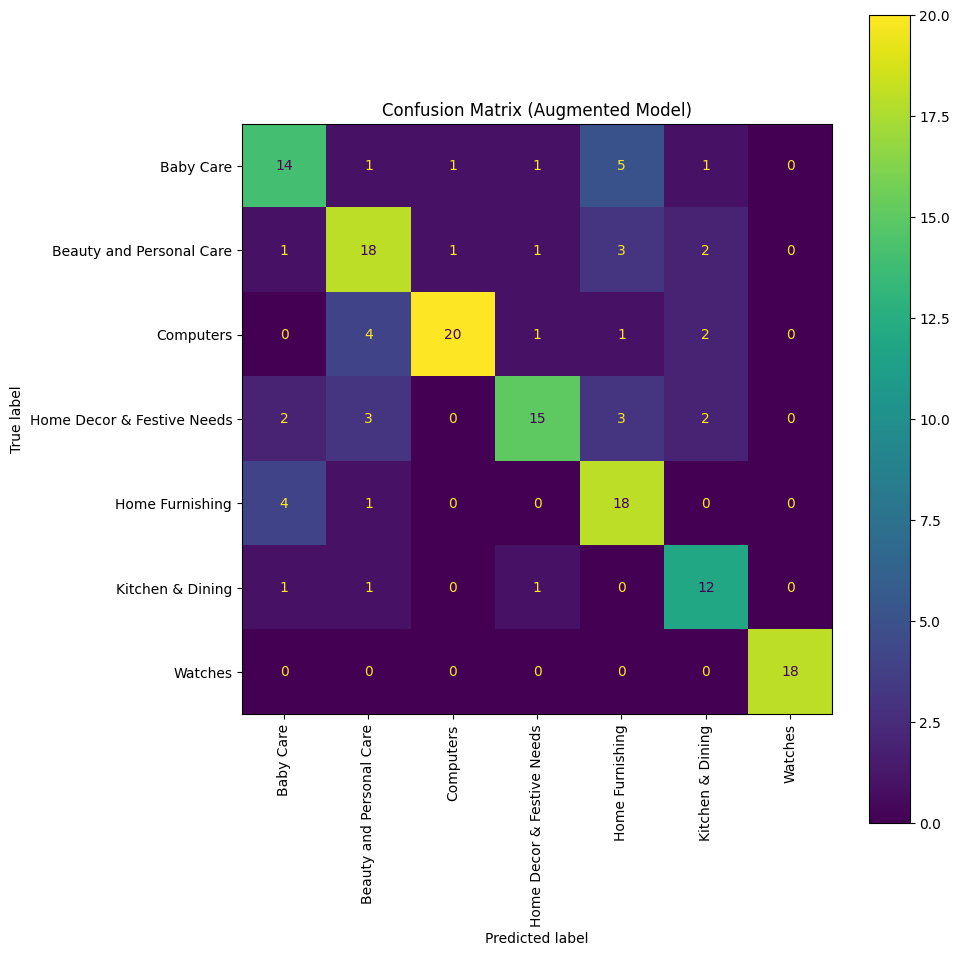

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import ast

# Load the augmented model
# model_augmented_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_model_augmented_trained.h5'
# try:
#     model_augmented = load_model(model_augmented_load_path)
# except Exception as e:
#     print(f"Error loading augmented model: {e}")
#     model_augmented = None # Set to None if loading fails

if model_augmented:
#     # Load test data and labels
#     X_test_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/X_test.npy'
#     y_test_onehot_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/y_test_onehot.npy'

#     try:
#         X_test = np.load(X_test_load_path)
#         y_test_onehot = np.load(y_test_onehot_load_path)
#     except FileNotFoundError:
#         print("Error: Test data not found. Please ensure X_test.npy and y_test_onehot.npy are in the specified output directory.")
#         X_test = None
#         y_test_onehot = None
#     except Exception as e:
#         print(f"Error loading test data: {e}")
#         X_test = None
#         y_test_onehot = None


    if X_test is not None and y_test_onehot is not None:
        # Recreate label_encoder
        # csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'
        # try:
        #     df = pd.read_csv(csv_file_path)
        #     df['top_level_category'] = df['product_category_tree'].apply(lambda x: x.split('>>')[0].strip().replace('[', '').replace(']', '').replace('"', '') if pd.notna(x) else None)
        #     df_filtered = df.dropna(subset=['top_level_category'])
        #     labels = df_filtered['top_level_category'].values
        #     label_encoder = LabelEncoder()
        #     label_encoder.fit(labels)

        # except FileNotFoundError:
        #     print(f"Error: The CSV file was not found at the specified path: {csv_file_path}. Cannot recreate label_encoder.")
        #     label_encoder = None
        # except Exception as e:
        #     print(f"An error occurred while recreating label_encoder: {e}")
        #     label_encoder = None

        if label_encoder:
            # Get predictions from the augmented model on the test set
            y_pred_onehot = model_augmented.predict(X_test)
            y_pred_classes = np.argmax(y_pred_onehot, axis=1)
            y_true_classes = np.argmax(y_test_onehot, axis=1)

            # Generate the confusion matrix
            cm = confusion_matrix(y_true_classes, y_pred_classes)

            # Get the unique labels present in the true classes of the test set
            unique_true_labels = np.unique(y_true_classes)
            class_labels = label_encoder.classes_[unique_true_labels]


            # Use ConfusionMatrixDisplay to visualize the confusion matrix
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
            fig, ax = plt.subplots(figsize=(10, 10)) # Adjust figure size as needed
            disp.plot(ax=ax, cmap='viridis', values_format='d') # Use a colormap and show integer values
            plt.title('Confusion Matrix (Augmented Model)')
            plt.xticks(rotation=90) # Rotate x-axis labels for better readability
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()

        else:
            print("label_encoder is not available. Cannot display confusion matrix with category names.")
    else:
        print("Test data is not available. Cannot generate confusion matrix.")
else:
    print("Augmented model was not loaded successfully. Cannot generate confusion matrix.")

5/5 ━━━━━━━━━━━━━━━━━━━━ 85s 17s/step
Number of misclassified images: 43


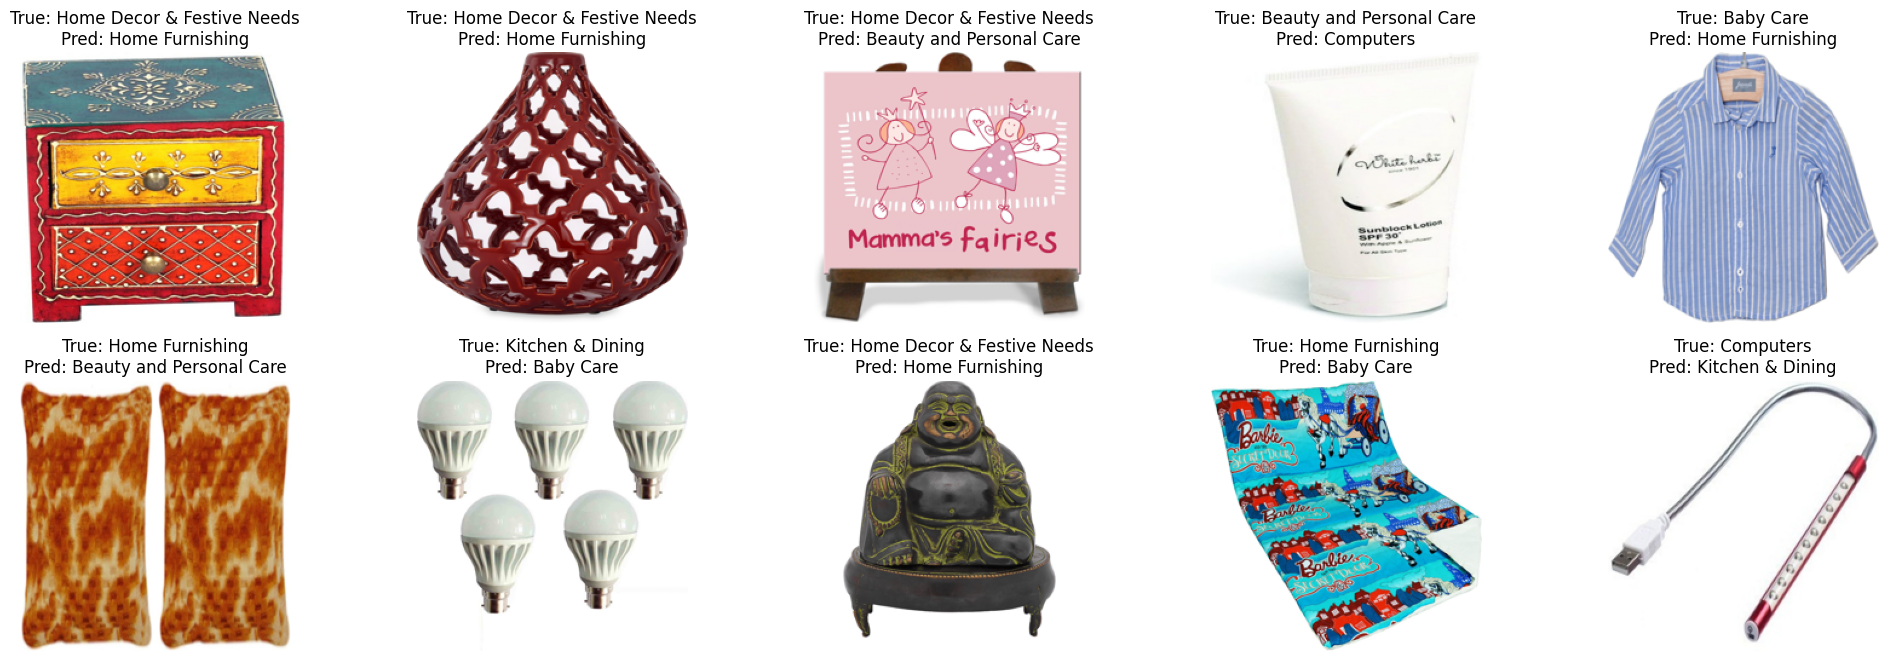

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import ast

# # Load the model
# model_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_model_augmented_trained.h5'
# try:
#     model_augmented = load_model(model_load_path)
# except Exception as e:
#     print(f"Error loading model: {e}")
#     model_augmented = None # Set to None if loading fails

if model_augmented:
    # Load test data and labels
    # X_test_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/X_test.npy'
    # y_test_onehot_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/y_test_onehot.npy'

    # try:
    #     X_test = np.load(X_test_load_path)
    #     y_test_onehot = np.load(y_test_onehot_load_path)
    # except FileNotFoundError:
    #     print("Error: Test data not found. Please ensure X_test.npy and y_test_onehot.npy are in the specified output directory.")
    #     X_test = None
    #     y_test_onehot = None
    # except Exception as e:
    #     print(f"Error loading test data: {e}")
    #     X_test = None
    #     y_test_onehot = None


    if X_test is not None and y_test_onehot is not None:
        # Recreate label_encoder
        csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'
        try:
            df = pd.read_csv(csv_file_path)
            df['top_level_category'] = df['product_category_tree'].apply(lambda x: x.split('>>')[0].strip().replace('[', '').replace(']', '').replace('"', '') if pd.notna(x) else None)
            df_filtered = df.dropna(subset=['top_level_category'])
            labels = df_filtered['top_level_category'].values
            label_encoder = LabelEncoder()
            label_encoder.fit(labels)

        except FileNotFoundError:
            print(f"Error: The CSV file was not found at the specified path: {csv_file_path}. Cannot recreate label_encoder.")
            label_encoder = None
        except Exception as e:
            print(f"An error occurred while recreating label_encoder: {e}")
            label_encoder = None

        if label_encoder:
            # Get predictions
            y_pred_onehot = model_augmented.predict(X_test)
            y_pred_classes = np.argmax(y_pred_onehot, axis=1)
            y_true_classes = np.argmax(y_test_onehot, axis=1)

            # Find indices of misclassified images
            misclassified_indices = np.where(y_true_classes != y_pred_classes)[0]

            print(f"Number of misclassified images: {len(misclassified_indices)}")

            # Display examples of misclassified images
            num_examples_to_show = min(len(misclassified_indices), 10) # Display up to 10 examples
            if num_examples_to_show > 0:
                plt.figure(figsize=(20, num_examples_to_show // 5 * 5))
                for i, misclassified_index in enumerate(misclassified_indices[:num_examples_to_show]):
                    # Get the misclassified image, true label, and predicted label
                    misclassified_image = X_test[misclassified_index]
                    true_class_index = y_true_classes[misclassified_index]
                    predicted_class_index = y_pred_classes[misclassified_index]

                    # Convert class indices back to original category names
                    true_category = label_encoder.classes_[true_class_index]
                    predicted_category = label_encoder.classes_[predicted_class_index]

                    # Plot the image and labels
                    plt.subplot(num_examples_to_show // 5 + 1, 5, i + 1)
                    plt.imshow(misclassified_image)
                    plt.title(f"True: {true_category}\nPred: {predicted_category}")
                    plt.axis('off')

                plt.tight_layout()
                plt.show()
            else:
                print("No misclassified images to display.")

        else:
            print("label_encoder is not available. Cannot display misclassified images with category names.")
    else:
        print("Test data is not available. Cannot identify misclassified images.")
else:
    print("Model was not loaded successfully. Cannot identify misclassified images.")

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import ast

# Load the model
# model_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_model_augmented_trained.h5'
# try:
#     model_augmented = load_model(model_load_path)
# except Exception as e:
#     print(f"Error loading model: {e}")
#     model_augmented = None # Set to None if loading fails

if model_augmented:
#     # Load test data and labels
#     X_test_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/X_test.npy'
#     y_test_onehot_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/y_test_onehot.npy'

#     try:
#         X_test = np.load(X_test_load_path)
#         y_test_onehot = np.load(y_test_onehot_load_path)
#     except FileNotFoundError:
#         print("Error: Test data not found. Please ensure X_test.npy and y_test_onehot.npy are in the specified output directory.")
#         X_test = None
#         y_test_onehot = None
#     except Exception as e:
#         print(f"Error loading test data: {e}")
#         X_test = None
#         y_test_onehot = None


    if X_test is not None and y_test_onehot is not None:
        # Recreate label_encoder
        csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'
        try:
            df = pd.read_csv(csv_file_path)
            df['top_level_category'] = df['product_category_tree'].apply(lambda x: x.split('>>')[0].strip().replace('[', '').replace(']', '').replace('"', '') if pd.notna(x) else None)
            df_filtered = df.dropna(subset=['top_level_category'])
            labels = df_filtered['top_level_category'].values
            label_encoder = LabelEncoder()
            label_encoder.fit(labels)

        except FileNotFoundError:
            print(f"Error: The CSV file was not found at the specified path: {csv_file_path}. Cannot recreate label_encoder.")
            label_encoder = None
        except Exception as e:
            print(f"An error occurred while recreating label_encoder: {e}")
            label_encoder = None

        if label_encoder:
            # Get predictions
            y_pred_onehot = model_augmented.predict(X_test)
            print(f"y_pred_onehot:{y_pred_onehot}")
            y_pred_classes = np.argmax(y_pred_onehot, axis=1)
            y_true_classes = np.argmax(y_test_onehot, axis=1)

            # Find indices of misclassified images
            misclassified_indices = np.where(y_true_classes != y_pred_classes)[0]

5/5 ━━━━━━━━━━━━━━━━━━━━ 98s 19s/step
y_pred_onehot:[[7.3322010e-01 5.8108030e-06 5.4824613e-06 ... 2.6617137e-01
  4.3871638e-05 1.3267406e-04]
 [1.5114389e-02 9.7378337e-01 5.9706494e-03 ... 6.6033594e-04
  4.2716195e-03 8.5090215e-07]
 [8.9780483e-03 4.0616244e-01 5.5015075e-01 ... 2.4838466e-03
  4.8488607e-03 2.1837471e-04]
 ...
 [8.6890429e-04 4.4876256e-06 1.3192822e-05 ... 5.1807237e-05
  1.9314932e-05 9.9902987e-01]
 [4.7625786e-01 1.7274367e-02 6.1870746e-02 ... 3.8435268e-01
  2.8368112e-02 2.4582073e-02]
 [3.3934518e-06 9.9969041e-01 1.0765918e-04 ... 3.1794796e-06
  1.7953286e-04 4.6489205e-07]]


In [33]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
import pickle
from sklearn.preprocessing import LabelEncoder
import ast

# Load test data and labels (assuming they are already loaded in the environment, if not, load them)
# try:
#     X_test_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/X_test.npy'
#     y_test_onehot_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/y_test_onehot.npy'
#     X_test = np.load(X_test_load_path)
#     y_test_onehot = np.load(y_test_onehot_load_path)
# except FileNotFoundError:
#     print("Error loading test data. Please ensure X_test.npy and y_test_onehot.npy are in the specified output directory.")
#     X_test = None
#     y_test_onehot = None
# except Exception as e:
#     print(f"Error loading test data: {e}")
#     X_test = None
#     y_test_onehot = None

# # Recreate label_encoder (assuming the CSV path is correct and accessible)
if X_test is not None and y_test_onehot is not None:
    csv_file_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/input/Flipkart/flipkart_com-ecommerce_sample_1050.csv'
    try:
        df = pd.read_csv(csv_file_path)
        df['top_level_category'] = df['product_category_tree'].apply(lambda x: x.split('>>')[0].strip().replace('[', '').replace(']', '').replace('"', '') if pd.notna(x) else None)
        df_filtered = df.dropna(subset=['top_level_category'])
        labels = df_filtered['top_level_category'].values
        label_encoder = LabelEncoder()
        label_encoder.fit(labels)
        class_names = label_encoder.classes_ # Get all class names
    except FileNotFoundError:
        print(f"Error: The CSV file was not found at the specified path: {csv_file_path}. Cannot recreate label_encoder.")
        label_encoder = None
        class_names = None
    except Exception as e:
        print(f"An error occurred while recreating label_encoder: {e}")
        label_encoder = None
        class_names = None


# # Load the non-augmented and augmented models
# model_non_augmented_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_model_not_augmented.h5'
# model_augmented_load_path = '/content/drive/Othercomputers/Mon ordinateur portable/ingénieur ia/projet 6/dev/output/image_classification_model_augmented_trained.h5'

# model_non_augmented = None
# try:
#     model_non_augmented = load_model(model_non_augmented_load_path)
# except Exception as e:
#     print(f"Error loading non-augmented model: {e}")

# model_augmented = None
# try:
#     model_augmented = load_model(model_augmented_load_path)
# except Exception as e:
#     print(f"Error loading augmented model: {e}")

model_non_augmented = model
if model_non_augmented and model_augmented and X_test is not None and y_test_onehot is not None and class_names is not None:
    print("\nGenerating comparison report:")

    # Get predictions and confusion matrices
    y_pred_onehot_non_augmented = model_non_augmented.predict(X_test)
    y_pred_classes_non_augmented = np.argmax(y_pred_onehot_non_augmented, axis=1)

    y_pred_onehot_augmented = model_augmented.predict(X_test)
    y_pred_classes_augmented = np.argmax(y_pred_onehot_augmented, axis=1)

    y_true_classes = np.argmax(y_test_onehot, axis=1)


    # Generate classification reports
    report_non_augmented = classification_report(
        y_true_classes,
        y_pred_classes_non_augmented,
        target_names=class_names,
        zero_division=0,
        output_dict=True # Get report as a dictionary
    )

    report_augmented = classification_report(
        y_true_classes,
        y_pred_classes_augmented,
        target_names=class_names,
        zero_division=0,
        output_dict=True # Get report as a dictionary
    )

    # Create a summary table
    summary_data = []

    # Add overall metrics (accuracy, macro avg, weighted avg)
    for metric in ['accuracy', 'macro avg', 'weighted avg']:
        summary_data.append({
            'VGG16 Metric': metric,
            'Non-Augmented Model': report_non_augmented[metric] if metric == 'accuracy' else report_non_augmented[metric]['f1-score'],
            'Augmented Model': report_augmented[metric] if metric == 'accuracy' else report_augmented[metric]['f1-score']
        })

    # Add class-wise F1-scores (using F1-score as a representative metric)
    for class_name in class_names:
         summary_data.append({
            'Metric': f'F1-score ({class_name})',
            'Non-Augmented Model': report_non_augmented[class_name]['f1-score'],
            'Augmented Model': report_augmented[class_name]['f1-score']
        })


    summary_df = pd.DataFrame(summary_data)
    print("\nComparison Summary Table (F1-score and Accuracy):")
    display(summary_df)


else:
    print("\nCould not generate comparison report. Please ensure models, test data, and label_encoder are loaded correctly.")


Generating comparison report:
5/5 ━━━━━━━━━━━━━━━━━━━━ 87s 17s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 85s 17s/step

Comparison Summary Table (F1-score and Accuracy):


,VGG16 Metric,Non-Augmented Model,Augmented Model,Metric
0,accuracy,0.803797,0.727848,NaN
1,macro avg,0.812121,0.736548,NaN
2,weighted avg,0.803663,0.729752,NaN
3,NaN,0.708333,0.622222,F1-score (Baby Care)
4,NaN,0.750000,0.666667,F1-score (Beauty and Personal Care)
5,NaN,0.836364,0.800000,F1-score (Computers)
6,NaN,0.791667,0.681818,F1-score (Home Decor & Festive Needs)
7,NaN,0.750000,0.679245,F1-score (Home Furnishing)
8,NaN,0.848485,0.705882,F1-score (Kitchen & Dining)
9,NaN,1.000000,1.000000,F1-score (Watches)


In [31]:
# Evaluate the augmented model on the test set
print("\nEvaluating the augmented model on the test set:")
loss_augmented, accuracy_augmented = model_augmented.evaluate(X_test, y_test_onehot, verbose=0)

print(f"Augmented Model Test Loss: {loss_augmented:.4f}")
print(f"Augmented Model Test Accuracy: {accuracy_augmented:.4f}")


Evaluating the augmented model on the test set:
Augmented Model Test Loss: 0.9014
Augmented Model Test Accuracy: 0.7278
